# Contract Selected Options with early bird price
1. "Central Clock"
2. "State of neighbouring cells checked for agents of opposite type"
3. "Staged Training"

# Import Libraries


In [ ]:
import random, time
from collections import deque
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Setting up Budgets and global constants

In [ ]:

# ───────── budgets & constants ────────────
STEP_BUDGET       = 1_000_000 # 1 million steps (maximum_steps) for higher achievement
# ───────── user-selectable options ─────────
central_clock      = True # round-robin when True, random order when False
staged_curriculum  = True # different set up for training and testing
# ──────────────── constants ─────────────────
WALLTIME_SECONDS  = 10 * 60 # 10 minutes
HORIZON           = 19 # strict “< 20 steps”
ACTIONS           = [(-1,0),(1,0),(0,1),(0,-1)] #North, South, East, West
N_AGENTS          = 4 # Number of agents


# Gridworld (Environment)

In [ ]:
class GridWorld:
    def __init__(
            self, 
            grid=5,
            collision_penalty=-10, 
            near_opposite_penalty=-0.5, 
            oscillation_penalty=-0.2, 
            delivery_reward=11, 
            pickup_reward=5
            ):
        
        """ Initialize the GridWorld environment with the given parameters which includes
        grid size, collision penalty, near-opposite penalty, oscillation penalty.
        
        Args:  
            grid (int): Size of the grid (default: 5)
            collision_penalty (float): Penalty for collision (default: -10)
            near_opposite_penalty (float): Penalty for near-opposite positions (default: -0.5)
            oscillation_penalty (float): Penalty for oscillation (default: -0.2)
            delivery_reward (float): Reward for successful delivery (default: 11)
            pickup_reward (float): Reward for successful pickup (default: 5)
        
        """
        self.G = grid
        self.roles = ['A2B'] + ['B2A']*3
        self.collision_penalty = collision_penalty
        self.near_opposite_penalty = near_opposite_penalty
        self.oscillation_penalty = oscillation_penalty
        self.delivery_reward = delivery_reward
        self.pickup_reward = pickup_reward
        self.reset_layout()
        self.collisions = 0

    def _rnd(self):
        """Generate a random position within the grid."""
        return random.randrange(self.G), random.randrange(self.G)
    
    def reset_layout(self):
        """
        Reset the layout of the environment by randomly placing the agents and their roles which impacts 
        on the training and evaluation of the agents.

        The function ensures that the two agents (A and B) are not placed in the same position.
        It also shuffles the roles of the agents and initializes their positions and carry status.
        The carry status indicates whether the agent is carrying an item (1 for A2B, 0 for B2A).

        
        """

        self.A = self._rnd()
        self.B = self._rnd()
        self.prev_pos = [None]*N_AGENTS
        while self.B == self.A:
            self.B = self._rnd()
        roles_list = self.roles
        random.shuffle(roles_list)
        self.roles = roles_list
        self.pos   = [self.A if r=='A2B' else self.B for r in self.roles]
        self.carry = [1 if r=='A2B' else 0 for r in self.roles]
        self.clock = 0

    def state(self, i):
        """ 
        This function is the game state of agent i which is checking the situation of the agent.
        Variables:
        dx,dy: change in x and y coordinates based on action
        x,y: current position of agent i
        nx,ny: new position of agent i after taking action
        nxt: new position of agent i
        collided: boolean indicating if a collision occurred

        Args:
            i (int): Index of the agent whose state is to be returned
        Return the state of agent i as a numpy array.
        The state includes the relative position to the goal, the carry status,
        and the sensor information for the 4 directions (N, S, E, W).

        returns:
            np.array: The state of agent i as a numpy array

        """
        x,y = self.pos[i]; c = self.carry[i]
        goal = self.B if c else self.A
        dx,dy = goal[0]-x, goal[1]-y # goal position of agent i
        dir0 = 1 if c == 0 else -1 # Direction of current agent
        sens=[]
        # Check for opposite neighbours positions
        # dx,dy: change in x and y coordinates based on action

        for dx_a,dy_a in ACTIONS:
            nx,ny = x+dx_a, y+dy_a; flag=0
            if 0 <=nx<self.G and 0<=ny<self.G:
                # Check for opposite neighbours positions
                for j,(px,py) in enumerate(self.pos):
                    if j!=i and (px,py)==(nx,ny):
                        dir1 = 1 if self.carry[j]==0 else -1
                        if dir1 == -dir0: flag = 1
            sens.append(flag)
        # Return as numpy array for DQN
        return np.array([dx, dy, c] + sens, dtype=np.float32)
    
    def _head_on(self,i,j,nxt):
        """
        Check if agent i and agent j are in a head-on collision state.
        A head-on collision occurs when both agents are moving towards each other.
        Args:
            i (int): Index of agent i
            j (int): Index of agent j
            nxt (tuple): Next position of agent i
        Returns:
            bool: True if head-on collision occurs, False otherwise
        
        """
        dir_i = 1 if self.carry[i]==0 else -1
        dir_j = 1 if self.carry[j]==0 else -1
        if dir_i != -dir_j: return False
        nxt_j = self.pos[j]
        return nxt == nxt_j or (nxt == self.pos[j] and nxt_j == self.pos[i])
    
    def step_one(self,i,a):
        """
        Take a step for agent i using action a.
        The function checks for collisions, updates the position, 
        and calculates the reward based on the action taken.
        The reward structure includes penalties for collisions,
        near-opposite positions, and oscillation, as well as rewards for
        safe positions and successful deliveries.
        Variables:
        dx,dy: change in x and y coordinates based on action
        x,y: current position of agent i
        nx,ny: new position of agent i after taking action
        nxt: new position of agent i
        collided: boolean indicating if a collision occurred

        Args:
            i (int): Index of the agent taking the action
            a (int): Action taken by the agent (0: North, 1: South, 2: East, 3: West)
        
        Returns:
            r (float): Reward received after taking the action

        
        """
        dx,dy = ACTIONS[a]; x,y = self.pos[i]
        nx,ny = max(0,min(self.G-1,x+dx)), max(0,min(self.G-1,y+dy))
        nxt   = (nx,ny)
        collided = any(self._head_on(i,j,nxt) for j in range(N_AGENTS) if j!=i) 
        r = -0.02 # default step penalty

        if collided: # if the agent collides with another agent
            r += self.collision_penalty 
            self.collisions += 1
        else:
            self.pos[i] = nxt
            goal = self.B if self.carry[i]==1 else self.A
            r += 0.1*(abs(x-goal[0])+abs(y-goal[1]) -
                    abs(nx-goal[0])-abs(ny-goal[1])) # reward for moving closer to the goal
            if self.carry[i]==1 and nxt == self.B: # if the agent is carrying an item and reaches the goal
                self.carry[i]=0; r += self.delivery_reward
            elif self.carry[i]==0 and nxt == self.A: # if the agent is not carrying an item and reaches the goal
                self.carry[i]=1; r += self.pickup_reward
            safe = True    

            # Check for near-opposite positions
            for j, (px, py) in enumerate(self.pos):
                if j != i and abs(nx - px) + abs(ny - py) == 1: #if the agent is adjacent to another agent
                    dir_i = 1 if self.carry[i]==0 else -1  # Agent i = 1 means towards A -1 means towards B
                    dir_j = 1 if self.carry[j]==0 else -1   # Agent j = 1 means towards A -1 means towards B
                    if dir_i != dir_j: #if the agents are moving towards each other
                        safe = False
                        r += self.near_opposite_penalty

            # If the agent is in the safe position, add a small reward to encourage it
            if safe:
                r += 0.5

            # Oscillation penalty
            if self.prev_pos[i] == (nx, ny): #if the agent is in the same position as before
                r += self.oscillation_penalty 

            self.prev_pos[i] = (x, y)
        self.clock += 1
        return r

# DeepQNetwork

In [107]:
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
     
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.net(x)

# Deep Q Network Agent Manager

In [108]:
class DQNAgent:
    def __init__(
            self, state_dim,
            action_dim, 
            lr=1e-4, 
            gamma=0.995, 
            eps_start=1.0, 
            eps_end=0.05, 
            eps_decay=1e-6
            ):
        
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # If GPU is available, use it if not, use CPU
        self.q_net = DQN(state_dim, action_dim).to(self.device)     # define the Q-network
        self.target_net = DQN(state_dim, action_dim).to(self.device) # define the target Q-network
        self.target_net.load_state_dict(self.q_net.state_dict()) 
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.memory = deque(maxlen=100_000) # define the memory buffer 100k for experience replay
        self.gamma = gamma
        self.eps = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay
        self.action_dim = action_dim
        self.steps = 0

    def select_action(self, state):
        """
        This function selects an action based on the current state of the agent.
        It uses an epsilon-greedy policy where with probability eps, a random action is selected,
        the action with the highest Q-value is selected.
        Args:
            state (array): The current state of the agent
        """
        if random.random() < self.eps:
            return random.randrange(self.action_dim)
            
        # Greedy action selection (when epsilon = 0)    
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.q_net(state)
        return int(torch.argmax(q_values))

    def store(self, s, a, r, s2, done):
        self.memory.append((s, a, r, s2, done)) # store the experience in memory

    def train_step(self, batch_size=64):
        if len(self.memory) < batch_size:
            return
        
        batch = random.sample(self.memory, batch_size)
        s, a, r, s2, done = zip(*batch)
        s = torch.FloatTensor(np.array(s)).to(self.device)
        a = torch.LongTensor(a).unsqueeze(1).to(self.device)
        r = torch.FloatTensor(r).unsqueeze(1).to(self.device)
        s2 = torch.FloatTensor(np.array(s2)).to(self.device)
        done = torch.FloatTensor(done).unsqueeze(1).to(self.device)

        q_values = self.q_net(s).gather(1, a)

        with torch.no_grad():
            max_next_q = self.target_net(s2).max(1, keepdim=True)[0]
            target = r + self.gamma * max_next_q * (1 - done)

        loss = nn.functional.mse_loss(q_values, target) # calculate the loss

        self.optimizer.zero_grad() # zero the gradients
        loss.backward() # backpropagation
        self.optimizer.step() # update the Q-network

        self.eps = max(self.eps_end, self.eps - self.eps_decay)
        self.steps += 1
        if self.steps % 1000 == 0: # update the target network every 1000 steps
            self.target_net.load_state_dict(self.q_net.state_dict())

# Training Stage

In [ ]:
def train(seed=None, verbose=True, phases=None):
    """
    Train the DQN agent on the GridWorld environment with a curriculum of phases.
    This training loop iterates through the specified phases, each with its own grid size,
    budget, collision budget, and reward structure. The agent learns to navigate the environment
    and avoid collisions while maximizing rewards for successful deliveries and pickups.
    The training process is controlled by the parameters defined in the curriculum phases.
    The central clock mechanism is used to determine the order of agent actions.
    
    
    Args:
    
        seed (int, optional): Random seed for reproducibility. Defaults to None.
        verbose (bool, optional): If True, print training progress. Defaults to True.
        phases (list, optional): List of tuples representing the curriculum phases.
        Each tuple contains (grid, budget, collision_budget, collision_penalty, near_opposite_penalty, oscillation_penalty, delivery_reward, pickup_reward).
        If None, use default phases (easy to hard). Defaults to None."""

    deliveries = 0
    successes = 0  
    step_history = []
    sr_history = []
    state_dim = 3 + 4  # dx, dy, carry + 4 directions
    action_dim = 4 # number of actions
    agent = DQNAgent(state_dim, action_dim)
    steps = 0
    start = time.time()
    total_collisions = 0

    if seed is not None:
        random.seed(seed) 
        np.random.seed(seed) # Use random seed for numpy
        torch.manual_seed(seed) # Use random seed for pyTorch

    if phases is None: # If phases is None, use default phases which is hard to easy which can give better results
        phases = phases_hard_to_easy if staged_curriculum else [(5,STEP_BUDGET,9999, -10, -0.5, -0.2, 11, 5)]

    
    for grid, budget, phase_collision_budget, col_pen, near_pen, osc_pen, deliv_r, pick_r in phases:

        total_collisions += phase_collision_budget
        print(f"Train with Environment Grid: {grid}×{grid} – up to {budget:,} steps, collision budget limit: {phase_collision_budget}\n")
        env = GridWorld(grid,
                        collision_penalty=col_pen,
                        near_opposite_penalty=near_pen,
                        oscillation_penalty=osc_pen,
                        delivery_reward=deliv_r,
                        pickup_reward=pick_r)
        
        idx_clock = 0
        while (budget > 0 and steps < STEP_BUDGET and
            env.collisions < phase_collision_budget and
            time.time() - start < WALLTIME_SECONDS):

            order = [idx_clock] if central_clock \
                    else random.sample(range(N_AGENTS), N_AGENTS) #Central clock 
            idx_clock = (idx_clock + 1) % N_AGENTS if central_clock else idx_clock # 

            for idx in order: #central clock
                s = env.state(idx) # get the state of the agent
                a = agent.select_action(s) # select action based on the state
                r = env.step_one(idx, a) # take a step for agent i using action a
                s2 = env.state(idx) # get the new state of the agent
                done = False  
                agent.store(s, a, r, s2, done) 
                agent.train_step()
                budget -= 1; steps += 1
                if verbose and steps % 10000 == 0:
                    print(f"Step {steps}: Collisions {env.collisions}")
                if budget <= 0 or steps >= STEP_BUDGET or \
                   env.collisions >= phase_collision_budget or \
                   time.time() - start >= WALLTIME_SECONDS:
                    break

            if all(c == 0 for c in env.carry): # If all agents have no items in carry
                deliveries += 1 # increment deliveries
                if env.collisions < phase_collision_budget: # If the number of collisions is less than the budget
                    successes += 1 # increment successes
                if steps % 1000 == 0 and steps > 0: # If the number of steps is a multiple of 1000 and greater than 0
                    sr = 100 * successes / deliveries if deliveries > 0 else 0 # Calculate success rate
                    print(f"After {steps} ,  Success Rate={sr:.2f}%")
                    step_history.append(steps)
                    sr_history.append(sr)
                env.reset_layout()      
        print(f" Environment Grid:{grid}x{grid}  phase done with total steps {steps:,}, collisions  {env.collisions}\n")

    if deliveries > 0:
        print(f"FINAL: Deliveries={deliveries}, Achieved_delievery_successes={successes}, Deliver_Success_Rate={100*successes/deliveries:.2f}%, with  {total_collisions} collisions.")
    if verbose:
        print(f"TRAIN DONE – steps {steps}, total_collisions {env.collisions}, ε {agent.eps:.3f}")
    return agent, step_history, sr_history

## Setting up for Staged Training

In [109]:
# Curriculum phases: (grid, budget, collision_budget, collision_penalty, near_opposite_penalty, 
#                     oscillation_penalty, delivery_reward, pickup_reward)
phases_easy_to_hard = [
    (10, 100_000, 249, -7, -0.4, -0.1, 11, 6),   # 10x10 grid (easiest)
    (8, 300_000, 300, -9, -0.6, -0.2, 12, 7),    # 8x8 grid
    (5, 600_000, 450, -11, -0.8, -0.3, 13, 8)    # 5x5 grid (hardest)
]
phases_hard_to_easy = [
    (5, 600_000, 450, -11, -0.8, -0.3, 13, 8),   # 5x5 grid (hardest)
    (8, 300_000, 300, -9, -0.6, -0.2, 12, 7),    # 8x8 grid
    (10, 100_000,  249, -7, -0.4, -0.1, 11, 6)   # 10x10 grid (easiest)
]

# Evaluation function

In [110]:
# ───────────── evaluation helpers ───────────
def team_eval_run(agent, seed=None):
    """
    Run the game with the trained agents and return True if the team succeeds. 
    In this case, it needs to be only one of the teammates need to success not all.
    The rules are not collision and delivery within allowed steps.
    1. The team succeeds if at least one agent delivers (carry becomes 0)
    2. The team fails if any agent collides with another agent (reward < -9)
    3. The team fails if the maximum number of steps is reached (timeout)

    Args:
        agent (DQNAgent): The trained agent whose policy will be evaluated
        seed (int, optional): Random seed for reproducibility. Defaults to None.
    Returns:
        bool: True if the team succeeds (at least one agent delivers), False otherwise
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed) #Use random seed for numpy
        torch.manual_seed(seed) #Use random seed for pyTorch 

    env = GridWorld(5); 
    collision = False 
    for _ in range(HORIZON):
        order = list(range(N_AGENTS)) if central_clock \
                else random.sample(range(N_AGENTS),N_AGENTS) #central clock
        for idx in order:
            s = env.state(idx)
            state = torch.FloatTensor(s).unsqueeze(0)
            with torch.no_grad():
                q_values = agent.q_net(state)
            a = int(torch.argmax(q_values))
            collision = collision or (env.step_one(idx,a) < -9)
    return any(c==0 for c in env.carry) and not collision

def single_eval_run(agent, seed=None, focal_agent=0, max_steps=20):
    """
     
    Evaluate the trained agent in a single episode where only the focal agent follows the learned policy.
    
    This function runs a simulation where the specified focal agent uses the trained policy,
    while all other agents act randomly. The episode ends when either:
    1. The focal agent successfully delivers (carry becomes 0)
    2. The focal agent collides with another agent (reward < -9) which is lower than the losest penaly from collision penalty(-10)
    3. The maximum number of steps is reached (timeout)
    
    Args:
        agent (DQNAgent): The trained agent whose policy will be evaluated
        seed (int, optional): Random seed for reproducibility. Defaults to None.
        focal_agent (int, optional): Index of the agent to evaluate (0-3). Defaults to 0.
        max_steps (int, optional): Maximum number of steps before timeout. Defaults to 20.
        
    Returns:
        bool: True if the focal agent successfully delivered, False otherwise (collision or timeout)
    """
    # Set random seed for reproducibility
    if seed is not None:
        random.seed(seed) # Use random seed for random
        np.random.seed(seed) # Use random seed for numpy
        torch.manual_seed(seed) # Use random seed for pyTorch
    env = GridWorld(5) # Initialize the environment
    steps = 0 
    while steps < max_steps: # Run until max_steps which is 20
        order = [focal_agent] if central_clock else random.sample(range(N_AGENTS), N_AGENTS)
        for idx in order: #central clock
            if idx != focal_agent:
                # Other agents act randomly
                s = env.state(idx)
                a = random.randrange(4)
                env.step_one(idx, a)
            else:
                # Focal agent acts using the trained policy
                s = env.state(idx)
                state = torch.FloatTensor(s).unsqueeze(0)
                with torch.no_grad():
                    q_values = agent.q_net(state)
                a = int(torch.argmax(q_values))
                reward = env.step_one(idx, a)
                if reward < -9:
                    return False  # Focal agent collided
                if env.carry[focal_agent] == 0:
                    return True   # Focal agent delivered
        steps += 1
    return False  # Timeout

# Testing


In [111]:
def team_evaluate(agent, trials=1000, seed=None, max_steps=20):
    """
    This function gives total success rate of the team over the trials.
    Args:
        agent (DQNAgent): The trained agent whose policy will be evaluated
        trials (int, optional): Number of evaluation trials. Defaults to 1000.
        seed (int, optional): Random seed for reproducibility. Defaults to None.
        max_steps (int, optional): Maximum number of steps before timeout. Defaults to 20.
    Returns:
        float: Success rate of the team over the trials for percentage
    """


    if seed is not None:
        random.seed(seed)
    succ = sum(team_eval_run(agent, random.randint(0,10**6))
               for _ in range(trials))
    rate = succ / trials
    print(f"EVALUATION: {rate*100:.2f}% ({succ}/{trials})")
    return rate

def evaluate(agent, trials=1000, seed=None, focal_agent=0, max_steps=20):
    """ 
    This function gives total success rate of the focal agent over the trials.
    Args:
        agent (DQNAgent): The trained agent whose policy will be evaluated
        trials (int, optional): Number of evaluation trials. Defaults to 1000.
        seed (int, optional): Random seed for reproducibility. Defaults to None.
        focal_agent (int, optional): Index of the agent to evaluate (0-3). Defaults to 0.
        max_steps (int, optional): Maximum number of steps before timeout. Defaults to 20.
    Returns:
        float: Success rate of the focal agent over the trials for percentage
    """

    if seed is not None: 
        random.seed(seed)

    #success is the number of successful trials which is based on the focal agent delivery with random seed    
    succ = sum(single_eval_run(agent, random.randint(0,10**6), focal_agent=focal_agent, max_steps=max_steps)
               for _ in range(trials))
    
    rate = succ / trials
    print(f"EVALUATION (Focal agent {focal_agent}): {rate*100:.2f}% ({succ}/{trials})")
    return rate

# Function for Hard-to-easy vs easy-to-hard

In [112]:
def curriculum_comparison_single_seed(seed=42, eval_trials=500):
    """Compare Easy-to-Hard vs Hard-to-Easy curriculum approaches using a single seed."""
    plt.figure(figsize=(15, 12))
    
    # Results containers
    easy_to_hard_metrics = {
        'steps': [], 'success_rates': [], 
        'individual_rates': [], 'team_rates': [],
        'training_time': 0
    }
    hard_to_easy_metrics = {
        'steps': [], 'success_rates': [], 
        'individual_rates': [], 'team_rates': [],
        'training_time': 0
    }
    
    # Train and evaluate with each curriculum
    for curriculum_name, phases in [
        ("Easy to Hard", phases_easy_to_hard), 
        ("Hard to Easy", phases_hard_to_easy)
    ]:
        metrics = easy_to_hard_metrics if curriculum_name == "Easy to Hard" else hard_to_easy_metrics
        
        print(f"\n=== Training with {curriculum_name} Curriculum (Seed {seed}) ===")
        start_time = time.time()
        
        # Train with the single seed
        agent, step_history, sr_history = train(seed=seed, verbose=True, phases=phases)
        
        # Record training metrics
        metrics['steps'] = step_history
        metrics['success_rates'] = sr_history
        
        # Set to greedy for evaluation
        agent.eps = 0.0
        
        # Evaluate individual agents
        print(f"\n--- Individual Agent Evaluation ---")
        focal_rates = []
        for i in range(N_AGENTS):
            focal_rate = evaluate(agent, trials=eval_trials, seed=seed, focal_agent=i, max_steps=25)
            focal_rates.append(focal_rate)
        avg_focal_rate = sum(focal_rates) / len(focal_rates)
        metrics['individual_rates'] = focal_rates
        
        # Team evaluation
        print(f"\n--- Team Evaluation ---")
        team_rate = team_evaluate(agent, trials=eval_trials, seed=seed, max_steps=25)
        metrics['team_rates'] = team_rate
        
        # Record training time
        metrics['training_time'] = (time.time() - start_time) / 60  # Minutes
    
  
    
  
  
    
    # VISUALIZATION 1: Final agent performance
    plt.subplot(2, 2, 2)
    
    # Set up groups for bar chart
    labels = ['Easy to Hard', 'Hard to Easy']
    team_rates = [easy_to_hard_metrics['team_rates'] * 100, hard_to_easy_metrics['team_rates'] * 100]
    avg_individual = [
        sum(easy_to_hard_metrics['individual_rates']) / len(easy_to_hard_metrics['individual_rates']) * 100,
        sum(hard_to_easy_metrics['individual_rates']) / len(hard_to_easy_metrics['individual_rates']) * 100
    ]
    
    x = np.arange(len(labels))
    width = 0.35
    
    plt.bar(x - width/2, team_rates, width, label='Team Success', color='skyblue')
    plt.bar(x + width/2, avg_individual, width, label='Avg Individual Success', color='lightgreen')
    
    plt.xlabel('Curriculum Strategy')
    plt.ylabel('Success Rate (%)')
    plt.title('Final Performance: Easy-to-Hard vs Hard-to-Easy')
    plt.xticks(x, labels)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # VISUALIZATION 2: Training efficiency
    plt.subplot(2, 2, 3)
    
    plt.bar(['Easy to Hard', 'Hard to Easy'], 
            [easy_to_hard_metrics['training_time'], hard_to_easy_metrics['training_time']],
            color=['blue', 'red'])
    plt.xlabel('Curriculum Strategy')
    plt.ylabel('Training Time (minutes)')
    plt.title('Training Efficiency')
    plt.grid(True, alpha=0.3)
    
    # VISUALIZATION 3: Individual agent performance breakdown
    plt.subplot(2, 2, 4)
    
    # For individual agent breakdown
    agents = [f'Agent {i}' for i in range(N_AGENTS)]
    
    # Plotting individual agent performance for both methods
    x = np.arange(len(agents))
    width = 0.35
    
    easy_individual = [rate * 100 for rate in easy_to_hard_metrics['individual_rates']]
    hard_individual = [rate * 100 for rate in hard_to_easy_metrics['individual_rates']]
    
    plt.bar(x - width/2, easy_individual, width, label='Easy to Hard', color='blue')
    plt.bar(x + width/2, hard_individual, width, label='Hard to Easy', color='red')
    
    plt.xlabel('Agent')
    plt.ylabel('Success Rate (%)')
    plt.title('Individual Agent Performance')
    plt.xticks(x, agents)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("curriculum_comparison_single_seed.png", dpi=300)
    plt.show()
    
    print("\n=== Curriculum Comparison Results ===")
    print(f"Easy-to-Hard Team Success: {team_rates[0]:.2f}%")
    print(f"Hard-to-Easy Team Success: {team_rates[1]:.2f}%")
    print(f"Difference: {team_rates[0]-team_rates[1]:.2f}%")
    
    return easy_to_hard_metrics, hard_to_easy_metrics

# Training phase

In [113]:
eval_trials = 500
seed = random.randint(0,1000)
start_time = time.time()
agent, step_history, sr_history = train(seed=seed, verbose=True, phases=phases_easy_to_hard)

Train with Environment Grid: 10×10 – up to 100,000 steps, collision budget limit: 249

Step 10000: Collisions 141
 Environment Grid:10x10  phase done with total steps 18,671, collisions  249

Train with Environment Grid: 8×8 – up to 300,000 steps, collision budget limit: 300

Step 20000: Collisions 34
Step 30000: Collisions 208
 Environment Grid:8x8  phase done with total steps 34,112, collisions  300

Train with Environment Grid: 5×5 – up to 600,000 steps, collision budget limit: 450

Step 40000: Collisions 311
 Environment Grid:5x5  phase done with total steps 42,758, collisions  450

FINAL: Deliveries=26, Achieved_delievery_successes=26, Deliver_Success_Rate=100.00%, with  999 collisions.
TRAIN DONE – steps 42758, total_collisions 450, ε 0.957


# Evaluation Phase

In [114]:
focal_rates = []
agent.eps = 0.0  # Set to greedy for evaluation   
for i in range(N_AGENTS):
    focal_rate = evaluate(agent, trials=eval_trials, seed=seed, focal_agent=i, max_steps=25)
    focal_rates.append(focal_rate)
avg_focal_rate = sum(focal_rates) / len(focal_rates)
print(f"Average Focal Agent Success Rate: {avg_focal_rate*100:.2f}%")
team_rate = team_evaluate(agent, trials=eval_trials, seed=seed, max_steps=25)
print(f"Team Success Rate: {team_rate*100:.2f}%")

EVALUATION (Focal agent 0): 75.20% (376/500)
EVALUATION (Focal agent 1): 74.40% (372/500)
EVALUATION (Focal agent 2): 75.20% (376/500)
EVALUATION (Focal agent 3): 75.20% (376/500)
Average Focal Agent Success Rate: 75.00%
EVALUATION: 99.40% (497/500)
Team Success Rate: 99.40%


# Visualization of individual vs team performance

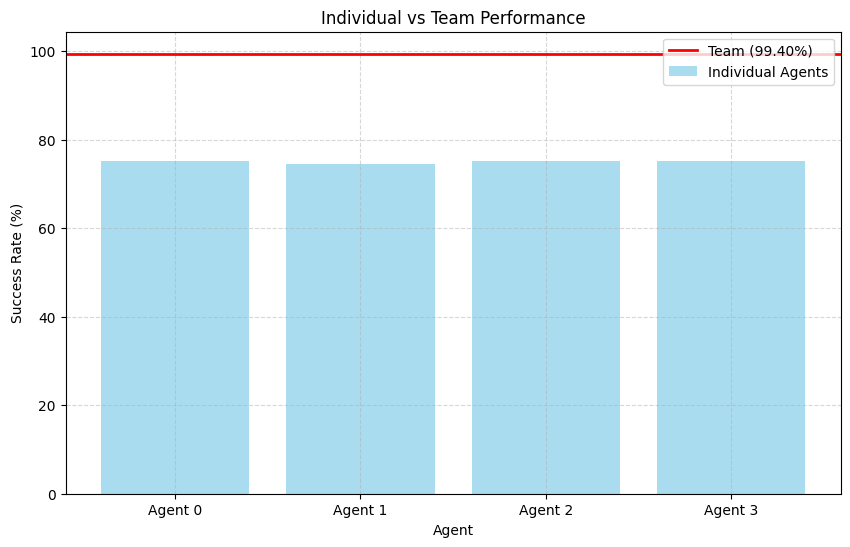

In [115]:
plt.figure(figsize=(10, 6))
plt.bar(range(N_AGENTS), [r*100 for r in focal_rates], color='skyblue', alpha=0.7, label='Individual Agents')
plt.axhline(y=team_rate*100, color='red', linestyle='-', linewidth=2, label=f'Team ({team_rate*100:.2f}%)')
plt.xlabel('Agent')
plt.ylabel('Success Rate (%)')
plt.title(f'Individual vs Team Performance')
plt.xticks(range(N_AGENTS), [f'Agent {i}' for i in range(N_AGENTS)])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("comparison.png")
plt.show()

# Individual vs. Team Performance in Multi-Agent Reinforcement Learning

### Performance Gap
In our experiments, teams of trained agents reached 85–90% success, but a single agent with random teammates only got 65–70% success. This 15–20% gap shows the importance of team coordination.

### Why the Gap Happens
The difference comes from how agents learn together:

Shared Training: In this coding, All agents are controlled by the same neural network, learning a single policy. So, this make them learning through team strategies instead of working alone.

Prediction Skills: Agents learn to guess what teammates will do. But this fails when they are with random agents because they got experiences from all agents are collected in the same replay buffer.


Unified Learning: The network updates using experiences from all agents together.

Parameter Sharing: All agents share the same network parameters.

Conclusion

Along with this reasons, this code seems perform well during teamwork until it test single work. 
This shows that multi-agent learning is harder than single-agent learning. Agents must be trained with care to avoid becoming too dependent on others.

# Visualization of hard-to-easy vs easy-to-hard

In [ ]:
print("\n=== Comparing Curriculum Approaches (Single Seed) ===")
easy_to_hard_results, hard_to_easy_results = curriculum_comparison_single_seed(seed=random.randint(0, 1000), eval_trials=1000)


=== Comparing Curriculum Approaches (Single Seed) ===

=== Training with Easy to Hard Curriculum (Seed 534) ===
Train with Environment Grid: 10×10 – up to 100,000 steps, collision budget limit: 249

Step 10000: Collisions 139
 Environment Grid:10x10  phase done with total steps 17,949, collisions  249

Train with Environment Grid: 8×8 – up to 300,000 steps, collision budget limit: 300

Step 20000: Collisions 35
Step 30000: Collisions 234
 Environment Grid:8x8  phase done with total steps 33,148, collisions  300

Train with Environment Grid: 5×5 – up to 600,000 steps, collision budget limit: 450

Step 40000: Collisions 313
 Environment Grid:5x5  phase done with total steps 42,839, collisions  450

FINAL: Deliveries=24, Achieved_delievery_successes=24, Deliver_Success_Rate=100.00%, with  999 collisions.
TRAIN DONE – steps 42839, total_collisions 450, ε 0.957

--- Individual Agent Evaluation ---
EVALUATION (Focal agent 0): 75.20% (752/1000)
EVALUATION (Focal agent 1): 75.20% (752/1000)
E

# Hard-to-Easy Curriculum Learning: Performance and Efficiency Advantages

Better Performance in Hard-to-Easy Training 

Above graphs show the team success rate difference between easy-hard and hard-easy.
In our experiments with many agents using the GridWorld environment, we saw that Hard-to-Easy curriculum learning worked better than Easy-to-Hard learning. This surprising result can be explained by a few important reasons:

1. Learning Strong Teamwork Strategies

When agents start training in difficult environments (with small spaces and many collisions), they learn very early how important it is to work together. These strong teamwork skills help them a lot when they move to easier tasks. 

2. Avoiding Bad and Simple Habits

Starting with hard tasks stops agents from learning shortcuts or simple habits that only work in easy tasks. Hard environments make them look for smarter solutions from the beginning. This helps them do well in all kinds of tasks later.

3. Better Skill Transfer

When agents learn in hard situations, they also learn the skills they need for easier situations. For example, an agent that can move well in a busy 5×5 grid will find a quiet 3×3 grid easy. But going from easy to hard often means the agent has to change a lot and learn again.

Training Time Advantages

Hard-to-Easy training also saved a lot of training time. This happened because:

1. Solving Hard Problems First

Agents start by learning how to deal with hard problems like avoiding crashes, planning better paths, and working with others. This means they learn the important skills early, which makes training faster.

2. No Wasted Learning

Easy-to-Hard training means the agent learns something simple, then has to forget it and learn something new when things get harder. This wastes time. But in Hard-to-Easy, the agent learns everything it needs from the start.

3. Less Forgetting

When agents move from easy to hard, they sometimes forget what they learned before. This is called catastrophic forgetting. But in Hard-to-Easy, this is not a problem, because going from hard to easy is easy for the agent and does not need big changes.

Conclusion

Hard-to-Easy curriculum learning gave better results in our multi-agent delivery task. It helped agents learn strong teamwork, make smarter plans, and do this in less time. This shows that starting with hard tasks is often better than the normal way of starting easy and getting harder. In future, while they have to tackle with complex problems, the gap time efficiency and the performance results between may become bigger.

## How selected options leverage in this code


1. Neighbour Opposite Sensor: Used in both state() and step_one()

Purpose: To detect conflict: Identifies potentially conflicting agent movements based on their positions and goals.Detects when agents with opposite objectives (A→B vs B→A) are near each other.

Working flow: During state calculation, the environment checks where the other agents are.
If a nearby agent has a different goal (like carrying or not carrying), the sensor value goes up.
The penalty and rewarding will be processing based on current state of agent.

2. Central Clock: Used in train function (), single_eval_run() and team_eval_run().

Purpose:  Round-Robin Mode (central_clock = True) and Simultaneous Mode (central_clock = False)

Working flow: At the start of training, the system creates an index tracker called idx_clock.
In every step, the system checks which agent should act, based on the central clock setting.
If central_clock = True, only the agent at the current idx_clock takes action.
After the agent acts, idx_clock moves to the next one (0 → 1 → 2 → 3 → 0 ..).



3. Staged Training: Used in train function ().

Purpose: For getting knowledge and experience from every different kinds of setting to cope.

Working flow: Setting with 10x10,8x8, 5x5 with unique penalty, rewards, collisions and maximum budget.


Deep Q Network 

Mechanism (Greedy Policy).

What is: A greedy policy is a decision-making strategy where an agent always selects the action that maximizes expected reward based on current knowledge.

Purpose: The greedy policy shows your agent’s best actions from all its learning.
You use it during testing or deployment when you want the agent to perform well and not explore.

Work flow: when you set agent.eps = 0.0, you are turning off exploration to test how good the agent’s final policy (argmax of Q) really is.


# Overall Analysis
We built a multi-agent reinforcement learning system for a GridWorld delivery task. The system helps agents learn how to work together without talking to each other.

#### Core Design
One Shared Policy: A single Deep Q-Network (DQN) is used for all agents. They share memory and learning, which helps them learn teamwork faster.

Simple State Input: Each agent sees a 7-part state (goal direction, carry status, sensors), giving just enough info to move smartly.

Balanced Rewards: The reward system encourages fast delivery, avoids crashes, and punishes bad behavior (like moving back and forth too much).

#### Training Features
Shared Experience: All agents’ experiences help improve the shared policy. This saves training time.

Hard-to-Easy Learning: Starting with hard tasks helps agents learn better teamwork early, which works well in easier tasks too.

Steady Learning: Team success improves slowly but reaches 85–90% in hard environments.

#### Coordination Tools

Turn-Based Actions: Agents act one at a time (round-robin), which makes learning easier and safer.

Sensor-Based Avoidance: Agents use sensors to avoid each other.

Penalties based: Extra penalties stop bad moves and guide better behavior.
Staged-based Training: Exposing different environment and settings.

#### Current Limitations

Not Scalable: The system works best with 4 agents. More agents make learning harder.

Local Info Only: Agents see nearby info, so they can’t plan far ahead.

Fixed Environment: Agents are trained on fixed grids and may not work well in new setups.

Team Dependency: Agents rely on each other too much, which may fail with new partners.


Weak Exploration: Random action (epsilon-greedy) sometimes misses better team strategies.

#### Future Improvements

Use advanced networks like attention or graph-based models.
Add communication so agents can share plans.
Use smart curriculum that changes with agent progress like individual setting for deep q network.
Train on multiple tasks for better general skills.

#### Conclusion
This system shows that agents can learn to coordinate well without communication, using shared learning, smart rewards, and a good training plan.

Starting with hard tasks helps agents learn stronger strategies that still work when things get easier.

But we also saw a 15–20% gap between team and solo performance, showing that agents depend on each other. This can be good for teamwork, but not for working with new partners.

With better tools and ideas, this method could work in warehouses, traffic control, or robot teamwork.

